# Exploratory Data Analysis — Airbnb Global Listings

This notebook explores the **raw** Airbnb dataset (494,954 listings × 89 columns) to understand its structure, distributions, missing values, and relationships. The findings here justify the preprocessing decisions made in `preprocessing.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

## 1. Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv("../data/airbnb-listings.csv", sep=";", low_memory=False)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(3)

Shape: (494954, 89)
Rows: 494,954  |  Columns: 89


,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,4008728,https://www.airbnb.com/rooms/4008728,20170402075052,2017-04-02,"Luxurious 3 bedroom, centrum, 180m2",‪This luxurious apartment is situated in the c...,In the heart of hip & lively Amsterdam Centrum...,‪This luxurious apartment is situated in the c...,none,There is a wide variety of cafes and restauran...,...,10.0,10.0,9.0,NaN,Amsterdam,strict,1.0,1.52,"52.36523660409065, 4.878249575101092","Host Has Profile Pic,Host Identity Verified,Is..."
1,7778612,https://www.airbnb.com/rooms/7778612,20170402075052,2017-04-02,Luxury apartment in city centre,"Beautiful, large (105m2, 2 floors) and quiet a...",1 living room 1 dining room 2 bedrooms 1 bathr...,"Beautiful, large (105m2, 2 floors) and quiet a...",none,Within a few minutes walking you'll be in the ...,...,10.0,10.0,9.0,NaN,Amsterdam,strict,1.0,0.81,"52.367309030897516, 4.8738407410699915","Host Is Superhost,Host Has Profile Pic,Host Id..."
2,8264596,https://www.airbnb.com/rooms/8264596,20170402075052,2017-04-02,Cosy apartment across Vondelpark,This central located apartment will make you f...,NaN,This central located apartment will make you f...,none,NaN,...,10.0,10.0,10.0,NaN,Amsterdam,flexible,1.0,0.05,"52.361943953804776, 4.866686522141489","Host Has Profile Pic,Host Identity Verified,Is..."


In [3]:
# Column names and data types
print("=" * 60)
print("DATA TYPES SUMMARY")
print("=" * 60)
print(df.dtypes.value_counts())
print("\n")
print("=" * 60)
print("DESCRIPTIVE STATISTICS (Numerical)")
print("=" * 60)
df.describe().T

DATA TYPES SUMMARY
object     55
float64    33
int64       1
Name: count, dtype: int64


DESCRIPTIVE STATISTICS (Numerical)


,count,mean,std,min,25%,50%,75%,max
Host ID,494954.0,3.234417e+07,3.172156e+07,19.000000,6.886060e+06,2.188181e+07,4.792177e+07,1.350885e+08
Host Response Rate,379884.0,9.337655e+01,1.759244e+01,0.000000,9.800000e+01,1.000000e+02,1.000000e+02,1.000000e+02
Host Listings Count,494449.0,9.549721e+00,5.719952e+01,0.000000,1.000000e+00,1.000000e+00,3.000000e+00,1.114000e+03
Host Total Listings Count,494448.0,9.549738e+00,5.719958e+01,0.000000,1.000000e+00,1.000000e+00,3.000000e+00,1.114000e+03
Latitude,494953.0,3.804229e+01,2.294143e+01,-38.224427,3.891312e+01,4.231089e+01,5.137542e+01,5.599489e+01
Longitude,494953.0,-1.502097e+01,7.036429e+01,-123.218712,-7.396922e+01,2.137584e+00,1.244485e+01,1.536378e+02
Accommodates,494891.0,3.311584e+00,2.094052e+00,1.000000,2.000000e+00,2.000000e+00,4.000000e+00,2.100000e+01
Bathrooms,493428.0,1.249632e+00,6.070292e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
Bedrooms,494328.0,1.378322e+00,9.425079e-01,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,9.600000e+01
Beds,494037.0,1.934525e+00,1.488128e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.900000e+01


## 2. Missing Values Analysis
Which columns have significant missing data? This determines what we can keep vs. drop.

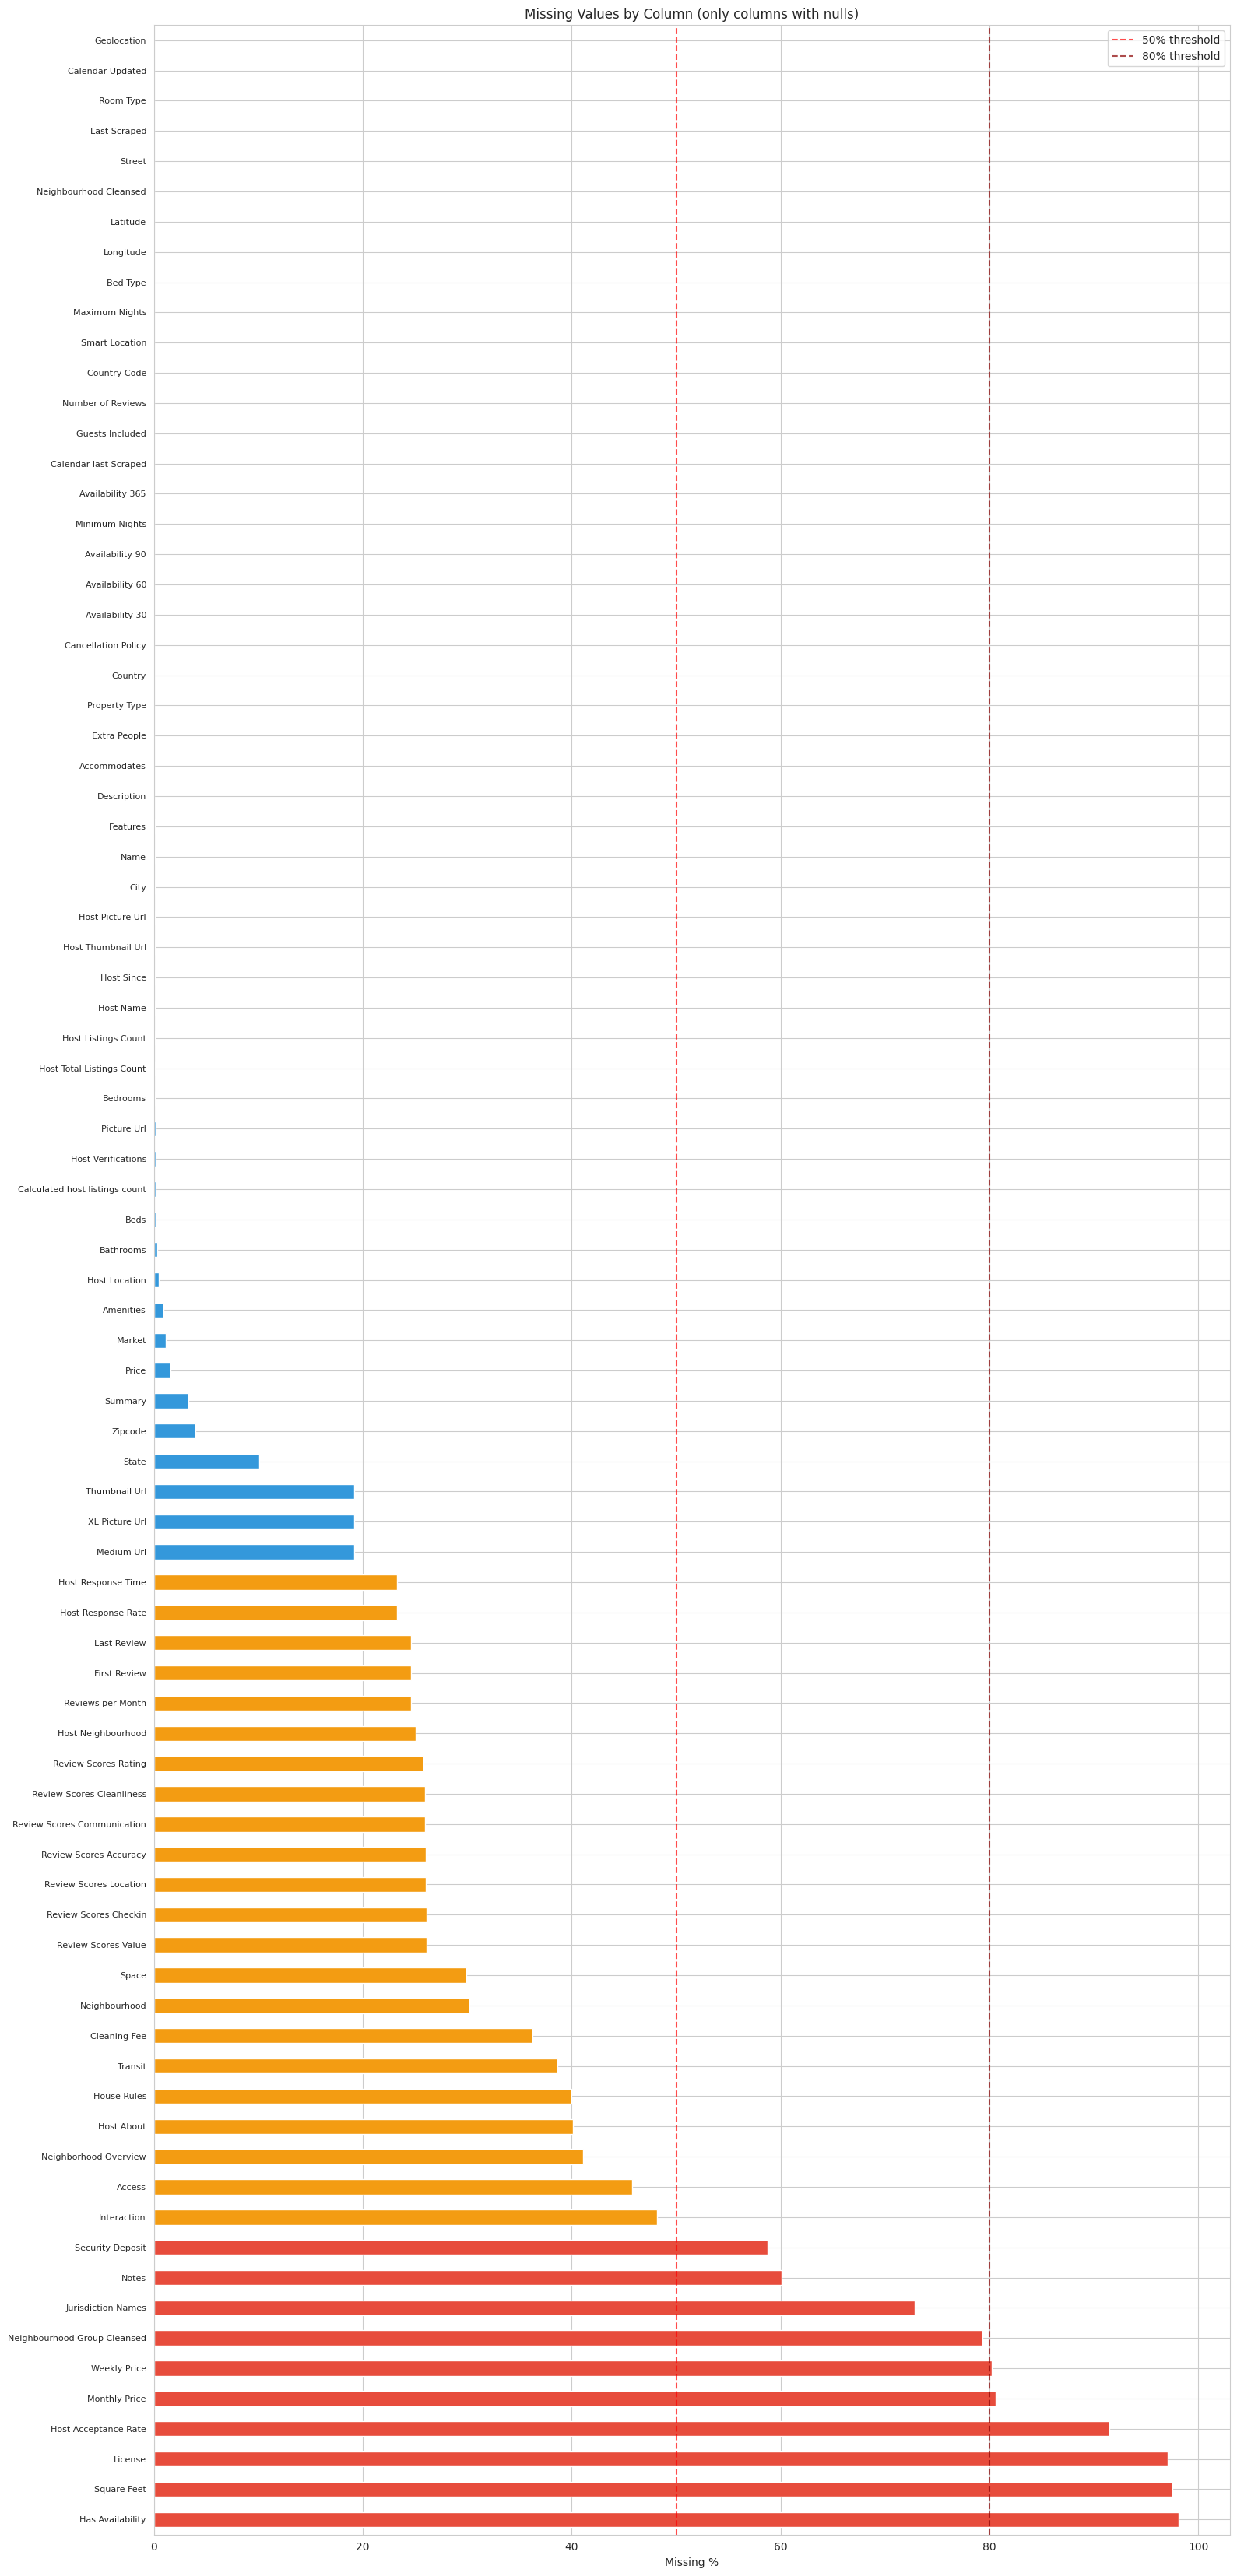


Columns with >50% missing:
Has Availability                98.119623
Square Feet                     97.533306
License                         97.051039
Host Acceptance Rate            91.462237
Monthly Price                   80.585873
Weekly Price                    80.251296
Neighbourhood Group Cleansed    79.359092
Jurisdiction Names              72.815049
Notes                           60.079118
Security Deposit                58.781624

Columns with 0% missing: 6 out of 89


In [4]:
# Null percentage per column, sorted descending
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(16, max(8, len(null_pct) * 0.4)))

null_pct.plot(
    kind="barh",
    ax=ax,
    color=[
        "#e74c3c" if v > 50 else "#f39c12" if v > 20 else "#3498db" for v in null_pct
    ],
)

ax.set_xlabel("Missing %")
ax.set_title("Missing Values by Column (only columns with nulls)")

ax.axvline(x=50, color="red", linestyle="--", alpha=0.7, label="50% threshold")
ax.axvline(x=80, color="darkred", linestyle="--", alpha=0.7, label="80% threshold")

# Reduce label size
ax.tick_params(axis="y", labelsize=8)


ax.legend()

plt.tight_layout()
plt.show()

print(f"\nColumns with >50% missing:\n{null_pct[null_pct > 50].to_string()}")
print(
    f"\nColumns with 0% missing: {(df.isnull().sum() == 0).sum()} out of {df.shape[1]}"
)

## 3. Categorical Columns Analysis
Examine the distribution of key categorical features.

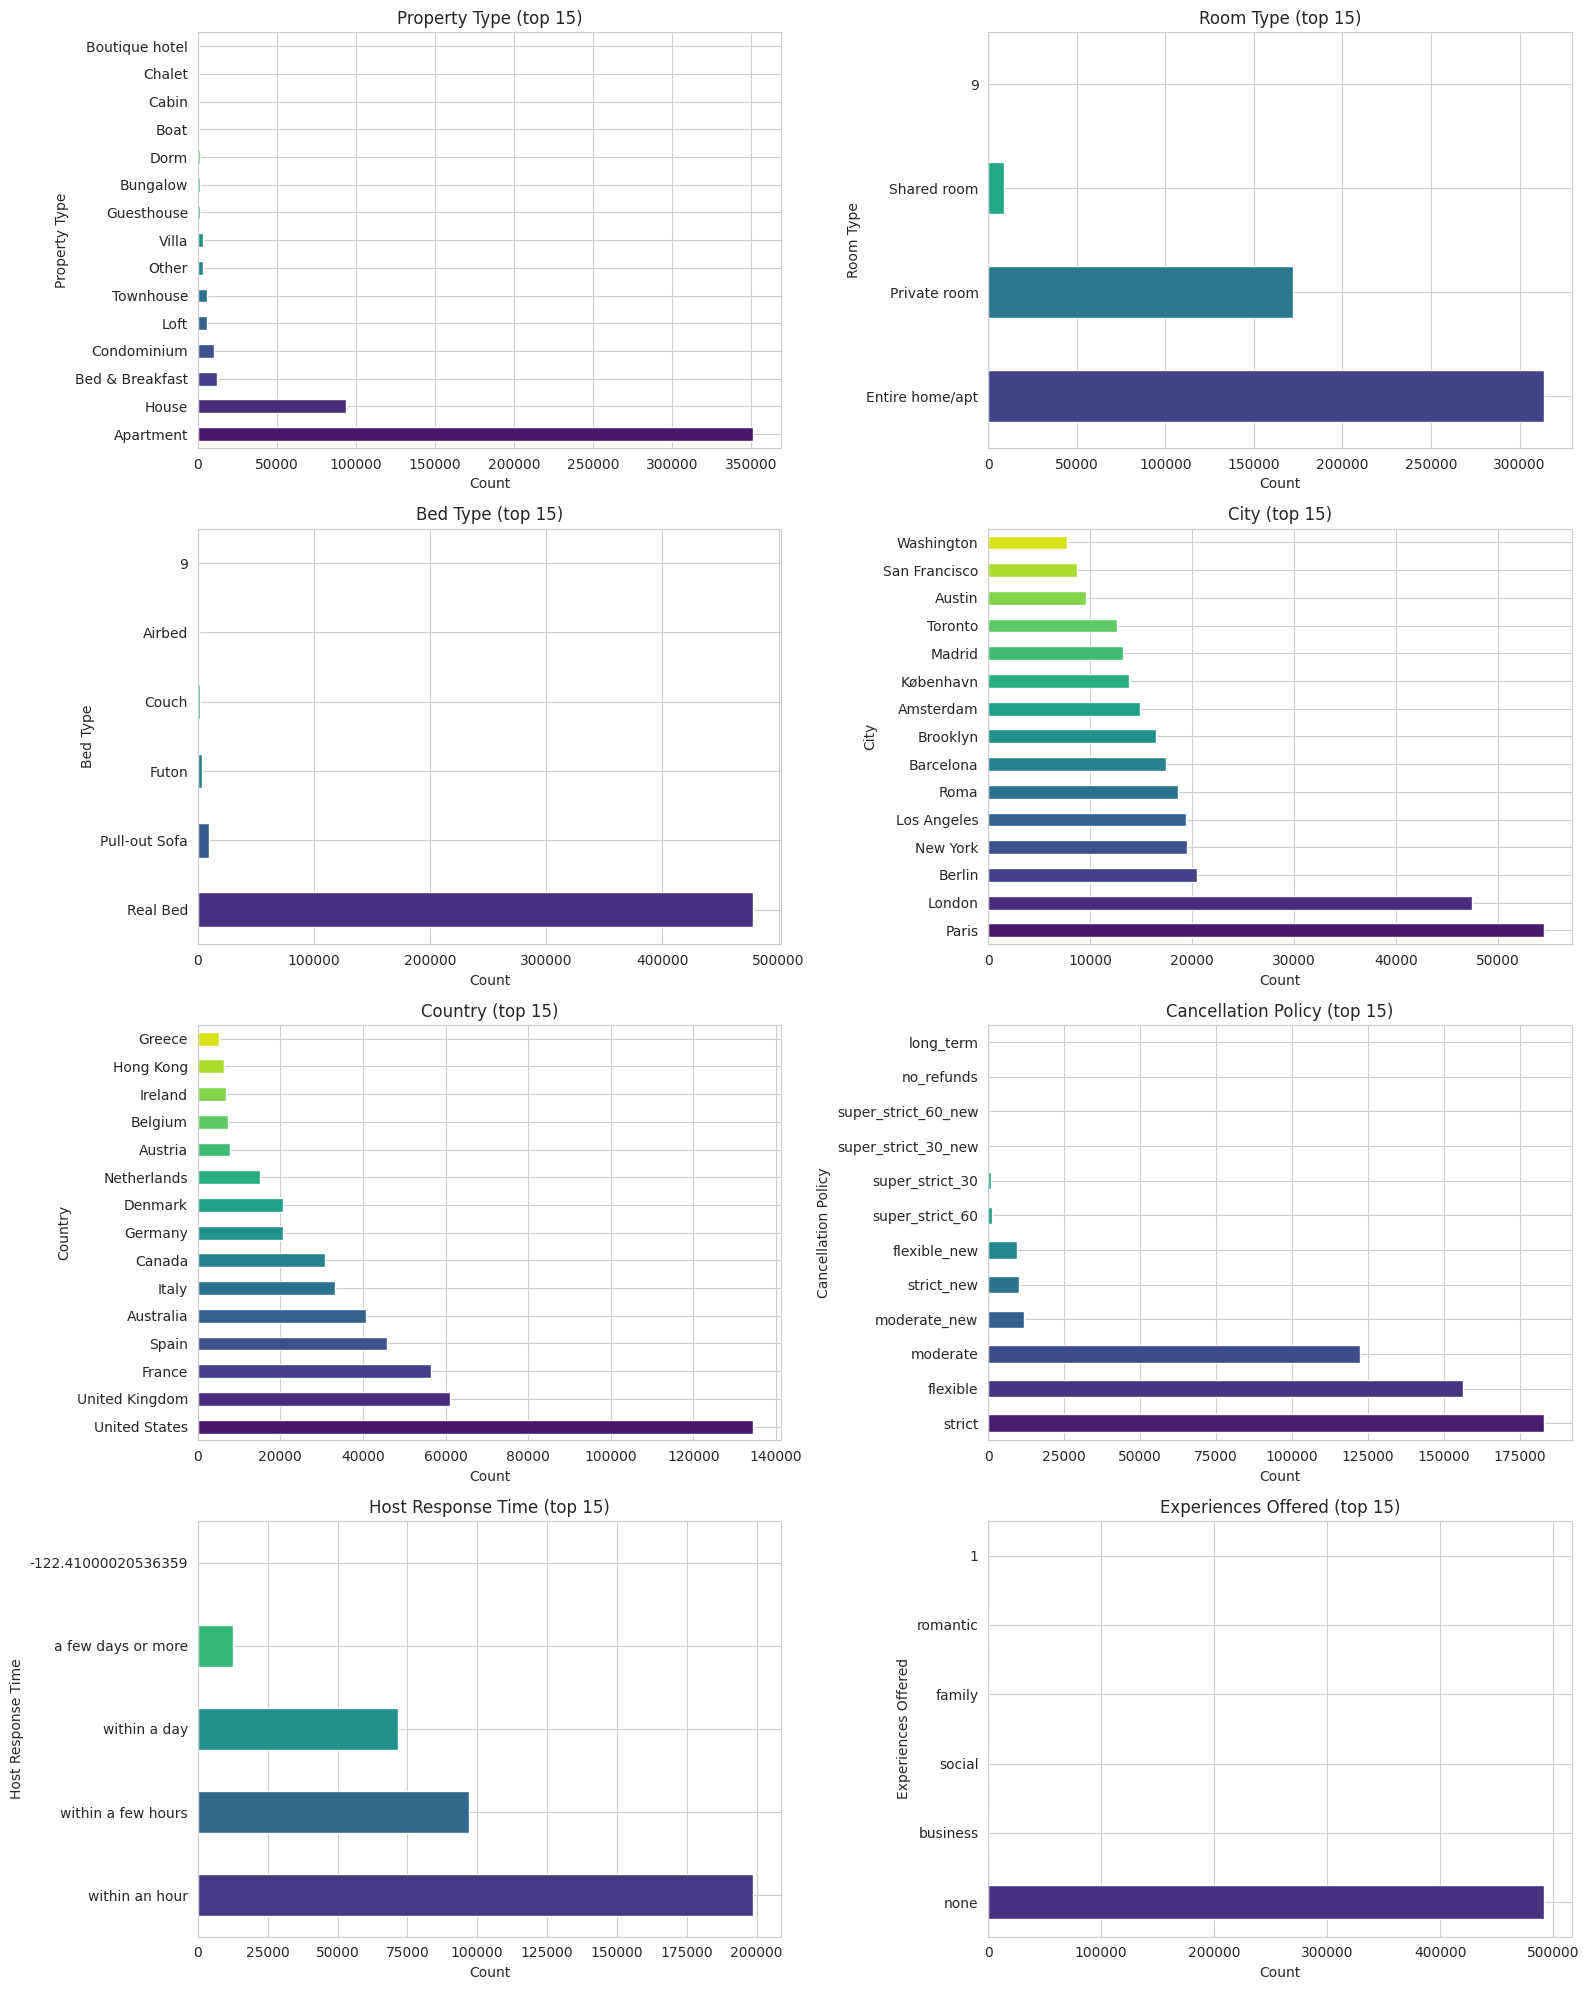

In [5]:
cat_cols = [
    "Property Type",
    "Room Type",
    "Bed Type",
    "City",
    "Country",
    "Cancellation Policy",
    "Host Response Time",
    "Experiences Offered",
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top_vals = df[col].value_counts().head(15)
    top_vals.plot(
        kind="barh", ax=axes[i], color=sns.color_palette("viridis", len(top_vals))
    )
    axes[i].set_title(f"{col} (top 15)")
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 4. Price Distribution & Outliers
The target variable for prediction. Understanding its distribution is critical.

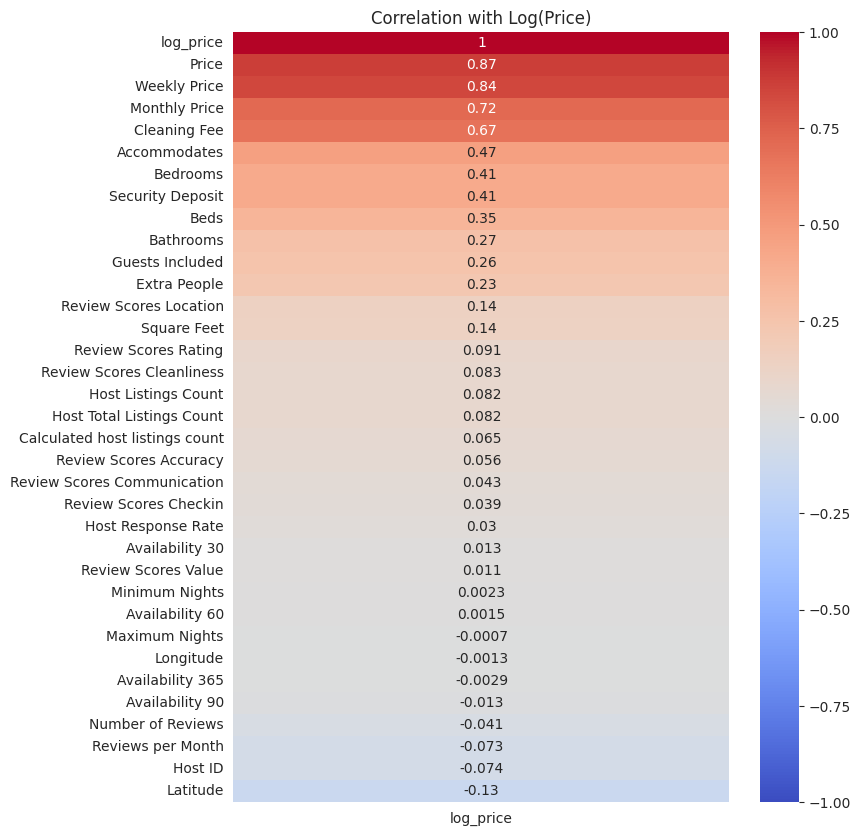


Top correlations with RAW Price:
Price               1.000000
log_price           0.871218
Monthly Price       0.838039
Cleaning Fee        0.739720
Weekly Price        0.716212
Security Deposit    0.395048
Accommodates        0.373973
Bedrooms            0.364242
Beds                0.294682
Extra People        0.274276
Name: Price, dtype: float64

Top correlations with LOG Price:
log_price           1.000000
Price               0.871218
Weekly Price        0.837064
Monthly Price       0.718638
Cleaning Fee        0.672541
Accommodates        0.465991
Bedrooms            0.412092
Security Deposit    0.409931
Beds                0.347824
Bathrooms           0.266746
Name: log_price, dtype: float64


In [6]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["log_price"] = np.log1p(df["Price"])

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 10))

log_corr = corr[["log_price"]].sort_values(by="log_price", ascending=False)

sns.heatmap(log_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation with Log(Price)")
plt.show()

print("\nTop correlations with RAW Price:")
print(corr["Price"].sort_values(ascending=False).head(10))

print("\nTop correlations with LOG Price:")
print(corr["log_price"].sort_values(ascending=False).head(10))

## 5. Numerical Features — Distributions
Histograms of key numerical columns to understand their spread.

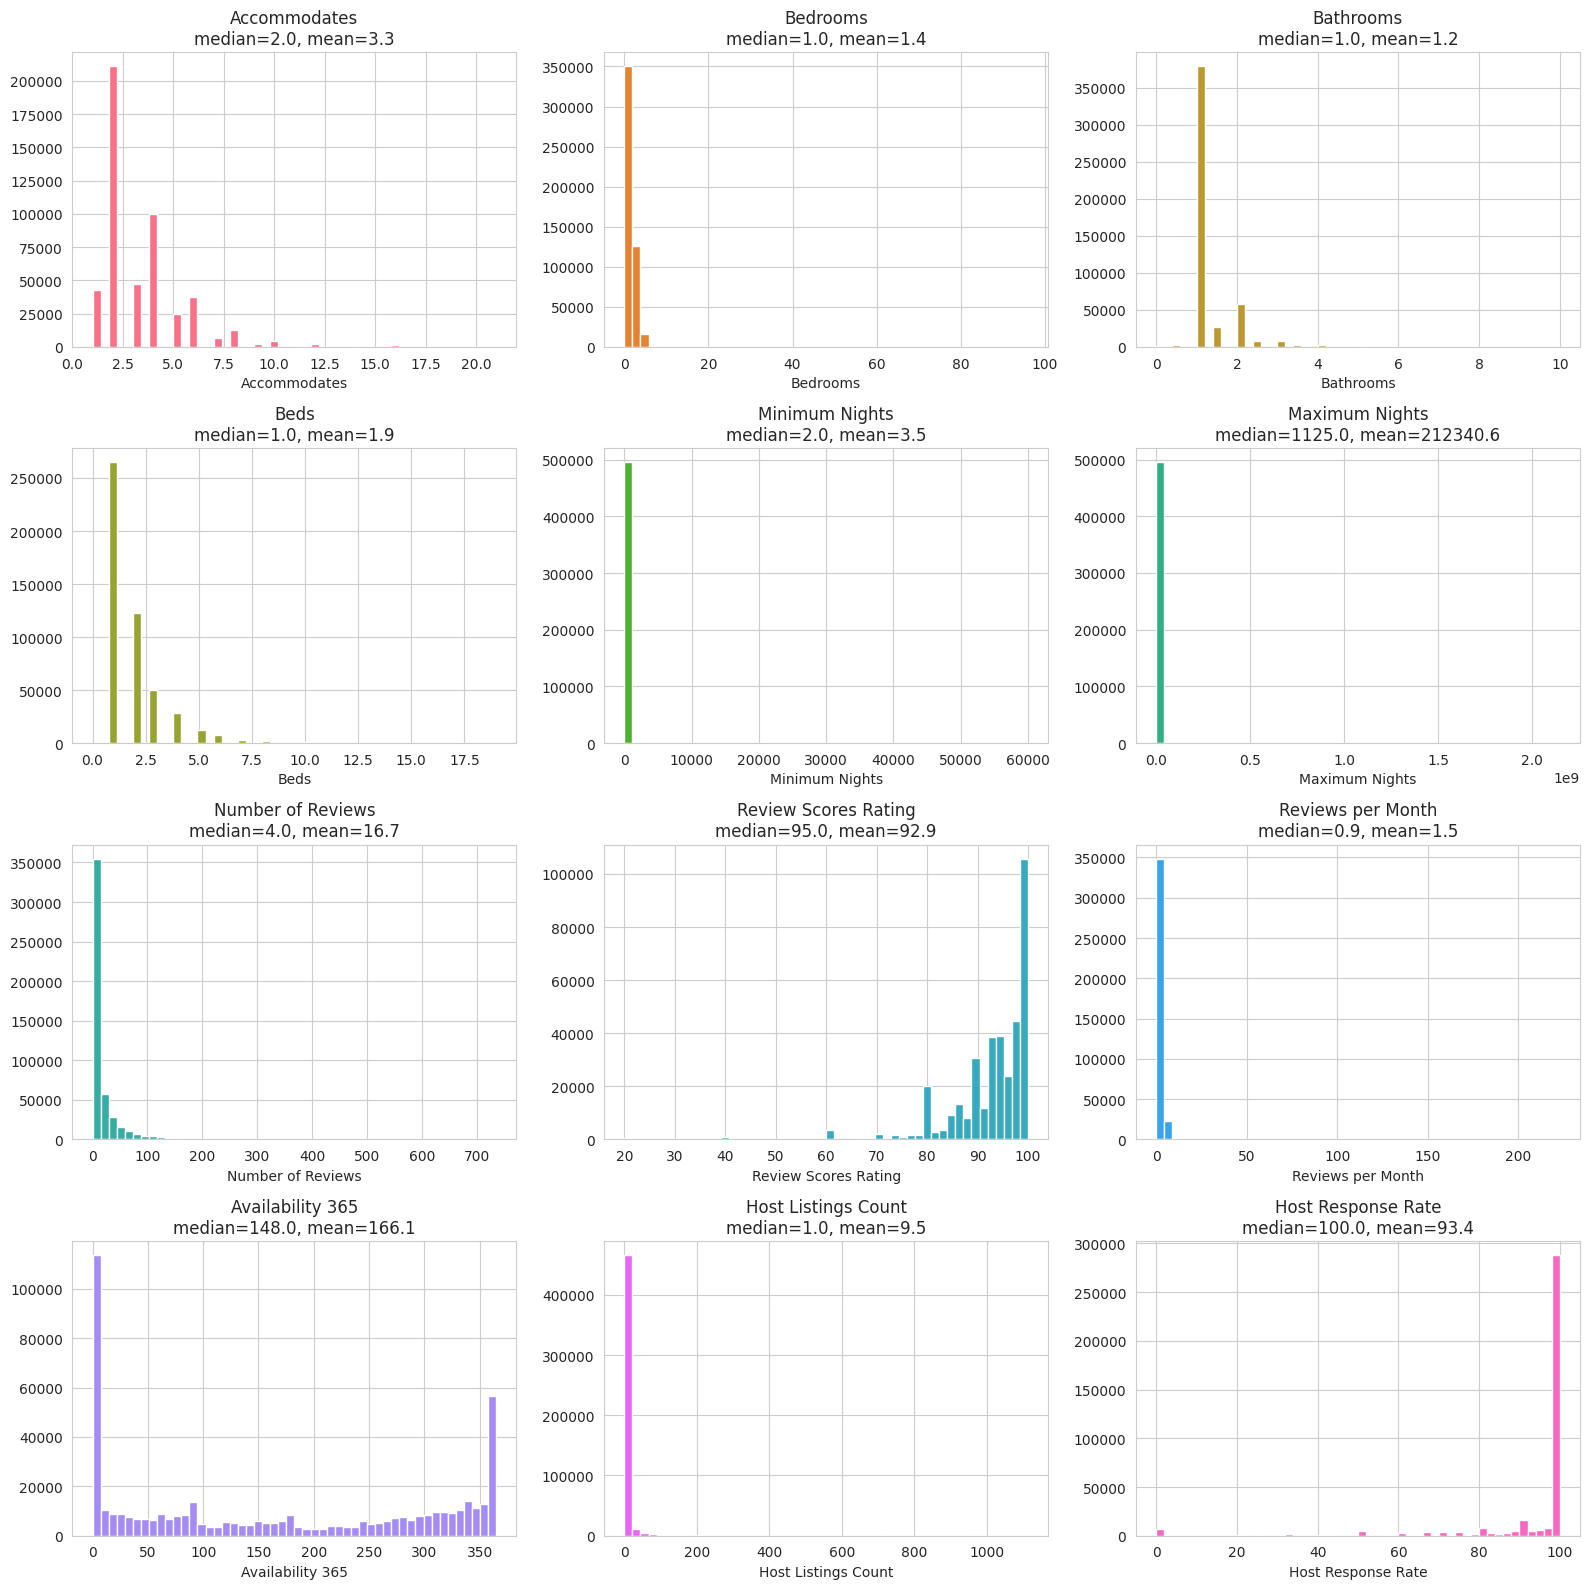

In [7]:
num_cols = [
    "Accommodates",
    "Bedrooms",
    "Bathrooms",
    "Beds",
    "Minimum Nights",
    "Maximum Nights",
    "Number of Reviews",
    "Review Scores Rating",
    "Reviews per Month",
    "Availability 365",
    "Host Listings Count",
    "Host Response Rate",
]

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(
        data, bins=50, color=sns.color_palette("husl", 12)[i], edgecolor="white"
    )
    axes[i].set_title(f"{col}\nmedian={data.median():.1f}, mean={data.mean():.1f}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

## 6. Price by Room Type & Property Type

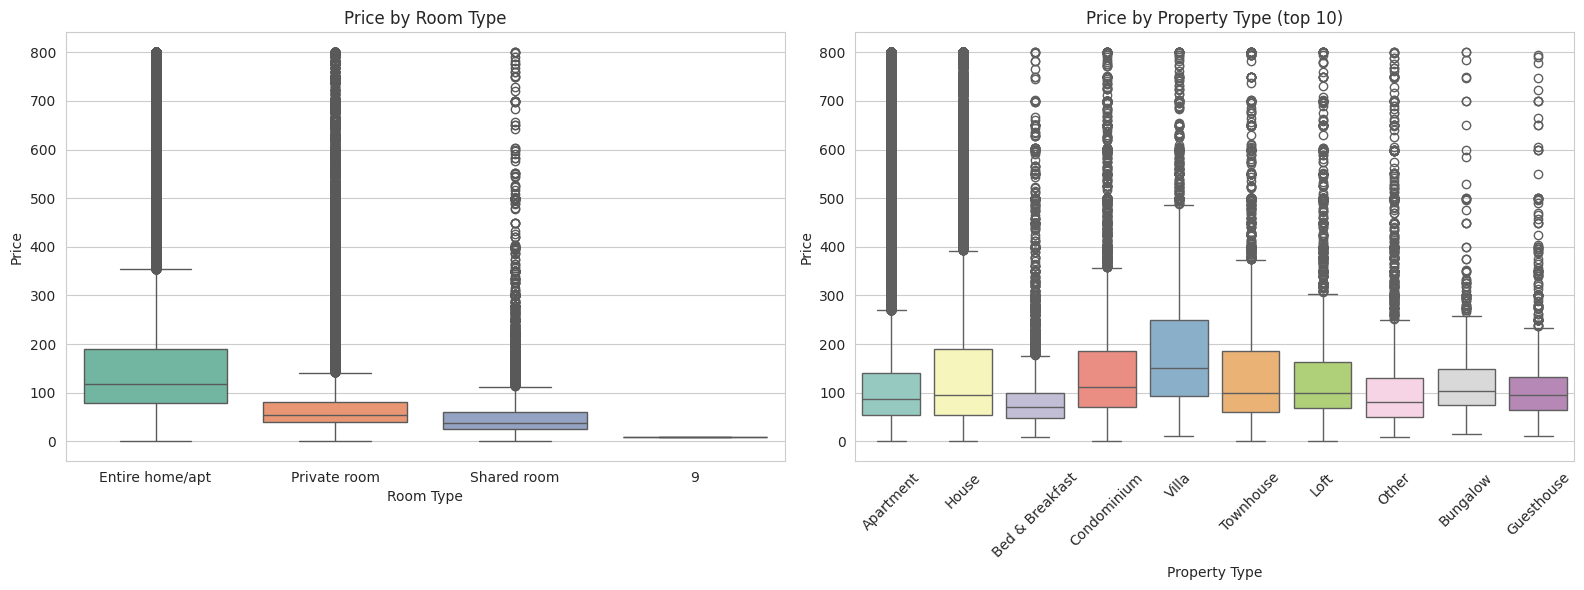

Median Price by Room Type:
Room Type
Entire home/apt    120.0
Private room        55.0
Shared room         37.0
9                    9.0


In [8]:
# Cap price at 99th percentile for cleaner visualization
price_cap = df["Price"].quantile(0.99)
df_viz = df[df["Price"] <= price_cap]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price by Room Type
sns.boxplot(data=df_viz, x="Room Type", y="Price", ax=axes[0], palette="Set2")
axes[0].set_title("Price by Room Type")

# Price by Property Type (top 10)
top_prop = df_viz["Property Type"].value_counts().head(10).index
df_top_prop = df_viz[df_viz["Property Type"].isin(top_prop)]
sns.boxplot(data=df_top_prop, x="Property Type", y="Price", ax=axes[1], palette="Set3")
axes[1].set_title("Price by Property Type (top 10)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Median price by room type
print("Median Price by Room Type:")
print(
    df.groupby("Room Type")["Price"].median().sort_values(ascending=False).to_string()
)

## 7. Correlation Heatmap
Which numerical features are most correlated with Price?

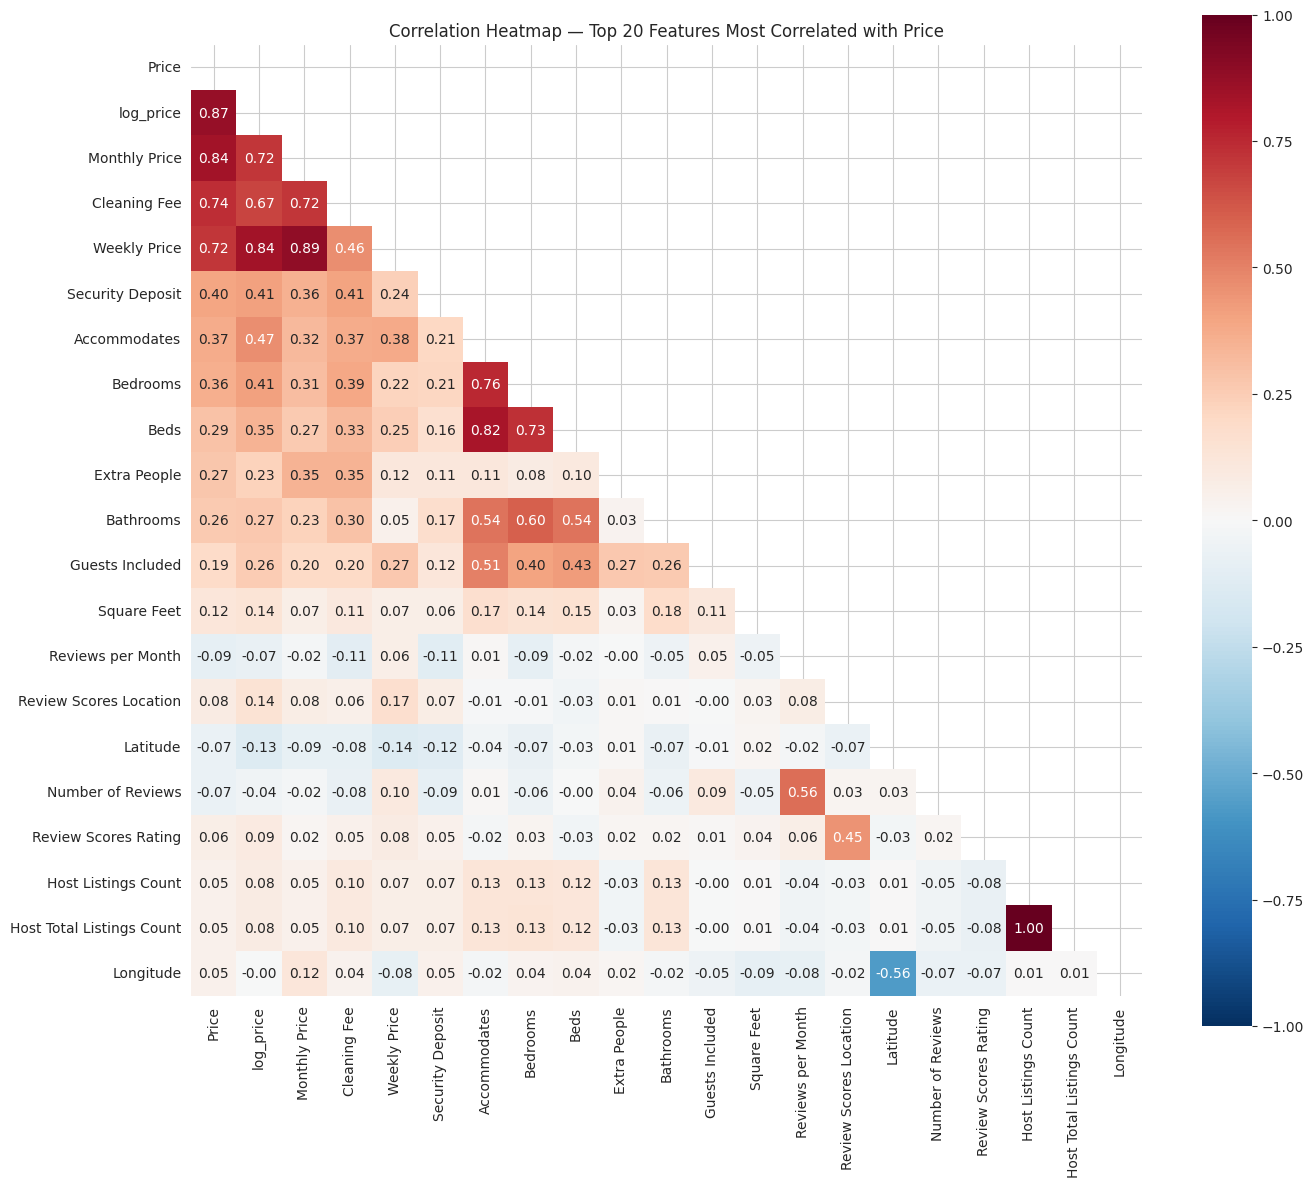


Top 15 correlations with Price:
Price                     1.000000
log_price                 0.871218
Monthly Price             0.838039
Cleaning Fee              0.739720
Weekly Price              0.716212
Security Deposit          0.395048
Accommodates              0.373973
Bedrooms                  0.364242
Beds                      0.294682
Extra People              0.274276
Bathrooms                 0.260599
Guests Included           0.193653
Square Feet               0.121704
Reviews per Month         0.089144
Review Scores Location    0.082470
Latitude                  0.066032


In [9]:
# Select numerical columns only
num_df = df.select_dtypes(include=[np.number])

# Top 20 features most correlated with Price
price_corr = (
    num_df.corr()["Price"].abs().sort_values(ascending=False).head(21)
)  # 21 to include Price itself
top_corr_cols = price_corr.index.tolist()

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = num_df[top_corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    square=True,
)
ax.set_title("Correlation Heatmap — Top 20 Features Most Correlated with Price")
plt.tight_layout()
plt.show()

print("\nTop 15 correlations with Price:")
print(price_corr.head(16).to_string())

## 8. Geographic Distribution
Scatter plot of listings by latitude/longitude, colored by price.

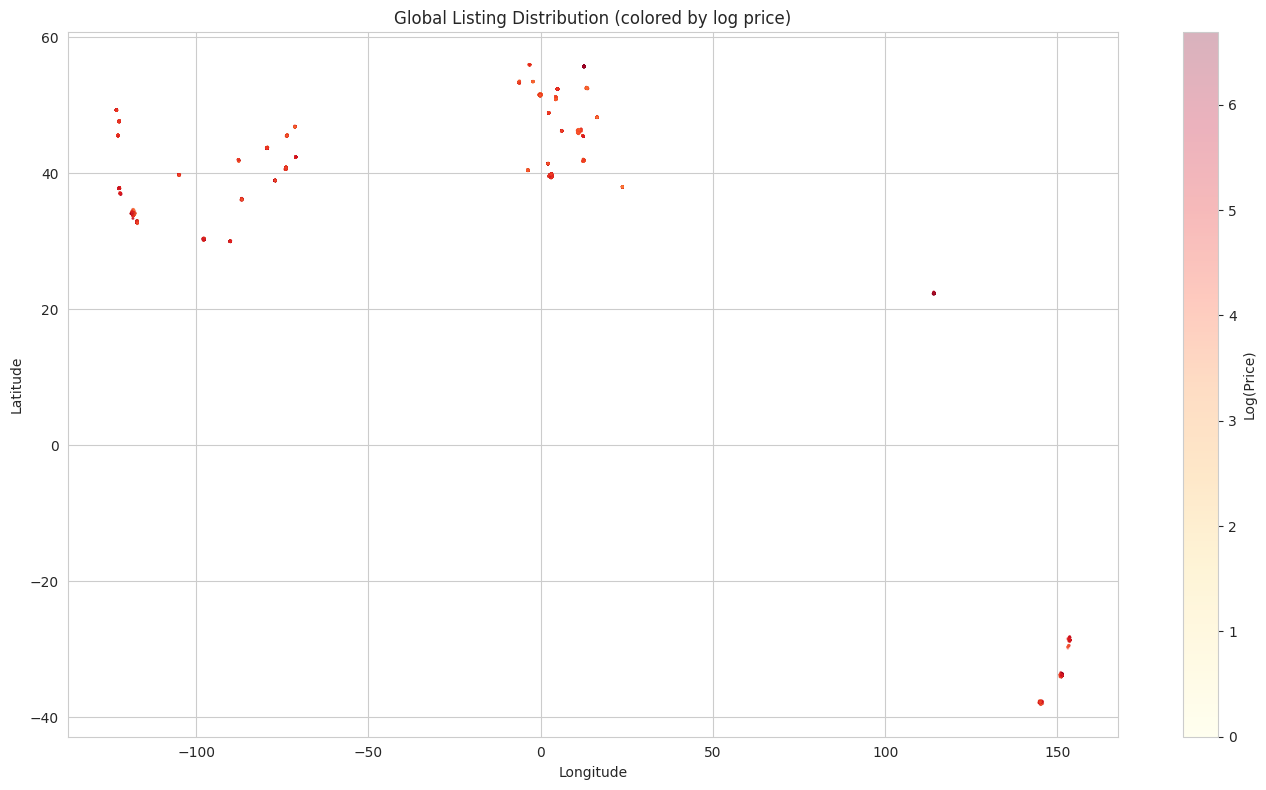

In [10]:
# Sample for performance (plotting 500K points is slow)
sample = df_viz.sample(n=min(50000, len(df_viz)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    sample["Longitude"],
    sample["Latitude"],
    c=np.log1p(sample["Price"]),
    cmap="YlOrRd",
    alpha=0.3,
    s=1,
)
plt.colorbar(scatter, ax=ax, label="Log(Price)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global Listing Distribution (colored by log price)")
plt.tight_layout()
plt.show()

## 9. Amenities Analysis
Parse the amenities string and find the most common amenities across all listings.

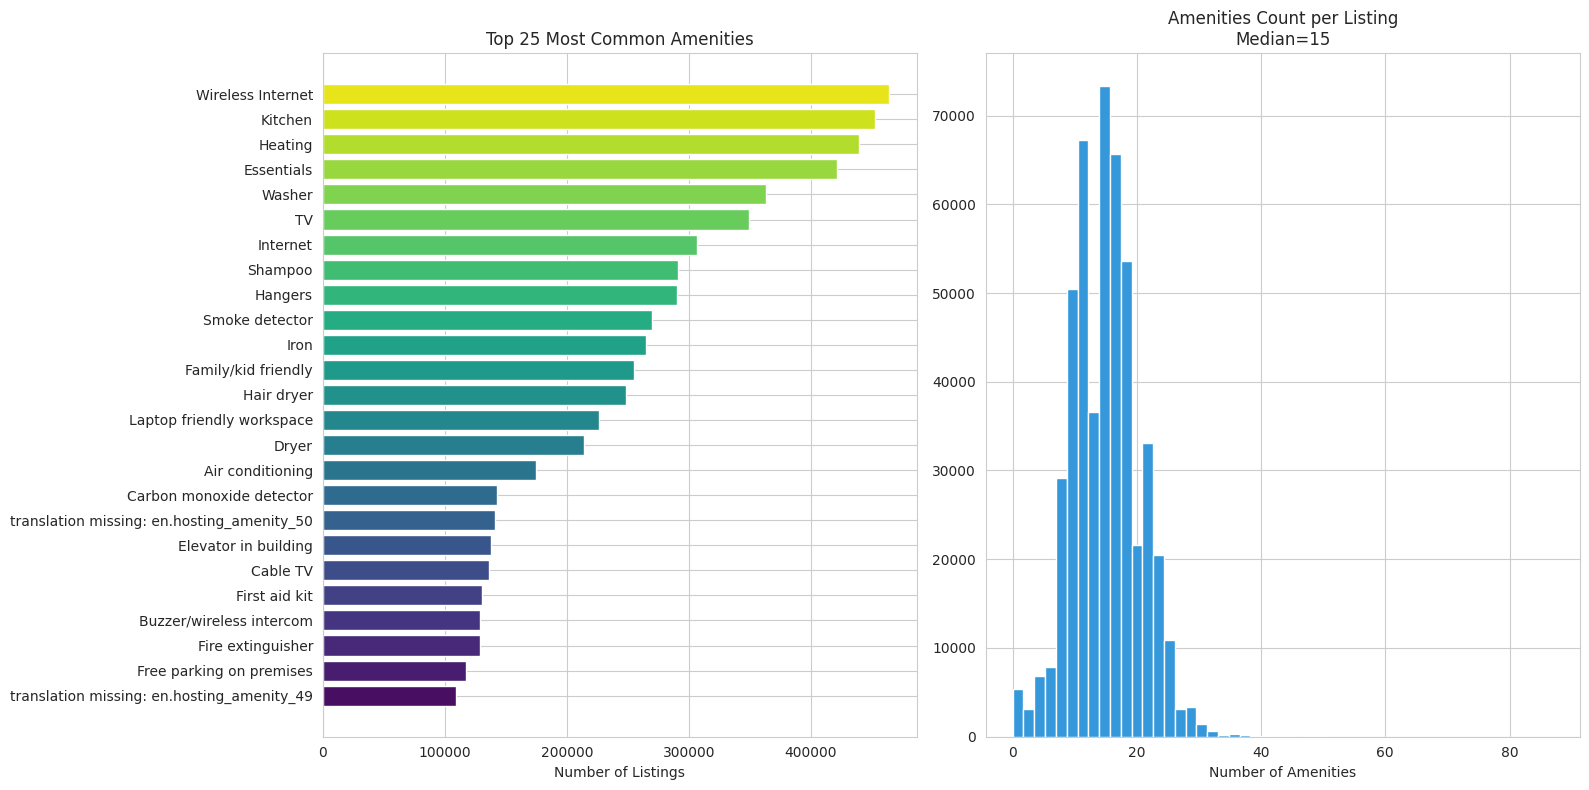

In [11]:
# Parse amenities
def parse_amenities(val):
    if pd.isna(val):
        return []
    val = val.strip("{}")
    return [a.strip().strip('"') for a in val.split(",") if a.strip()]


amenity_lists = df["Amenities"].apply(parse_amenities)
amenity_counts = Counter()
for lst in amenity_lists:
    amenity_counts.update(lst)

# Top 25 amenities
top_25 = amenity_counts.most_common(25)
amenity_names, amenity_freq = zip(*top_25)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart of top amenities
axes[0].barh(
    list(reversed(amenity_names)),
    list(reversed(amenity_freq)),
    color=sns.color_palette("viridis", 25),
)
axes[0].set_title("Top 25 Most Common Amenities")
axes[0].set_xlabel("Number of Listings")

# Amenities count distribution
amenity_count_per_listing = amenity_lists.apply(len)
axes[1].hist(amenity_count_per_listing, bins=50, color="#3498db", edgecolor="white")
axes[1].set_title(
    f"Amenities Count per Listing\nMedian={amenity_count_per_listing.median():.0f}"
)
axes[1].set_xlabel("Number of Amenities")

plt.tight_layout()
plt.show()

## 10. Review Scores Analysis

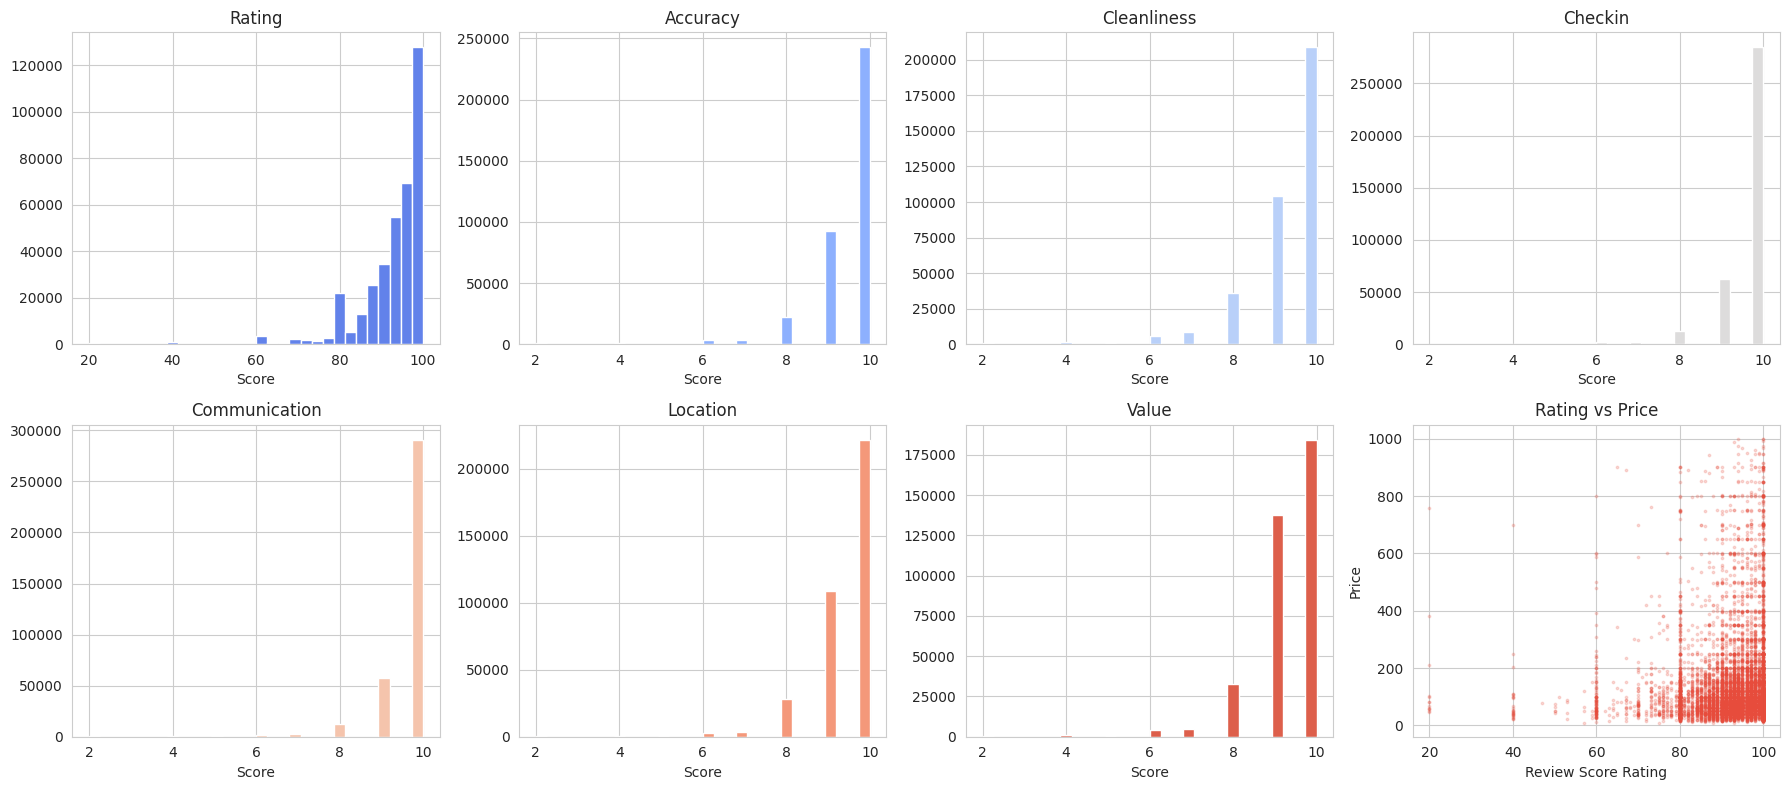

In [12]:
review_cols = [
    "Review Scores Rating",
    "Review Scores Accuracy",
    "Review Scores Cleanliness",
    "Review Scores Checkin",
    "Review Scores Communication",
    "Review Scores Location",
    "Review Scores Value",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(review_cols):
    data = df[col].dropna()
    axes[i].hist(
        data, bins=30, color=sns.color_palette("coolwarm", 7)[i], edgecolor="white"
    )
    axes[i].set_title(col.replace("Review Scores ", ""))
    axes[i].set_xlabel("Score")

# Review Scores Rating vs Price
axes[7].scatter(
    df[df["Review Scores Rating"].notna()].sample(10000, random_state=42)["Review Scores Rating"],
    df.loc[df["Review Scores Rating"].notna()]["Price"].sample(10000, random_state=42),
    alpha=0.2,
    s=3,
    color="#e74c3c",
)
axes[7].set_title("Rating vs Price")
axes[7].set_xlabel("Review Score Rating")
axes[7].set_ylabel("Price")

plt.tight_layout()
plt.show()

## 11. Host Analysis
Host tenure, listing count, and response rate distributions.

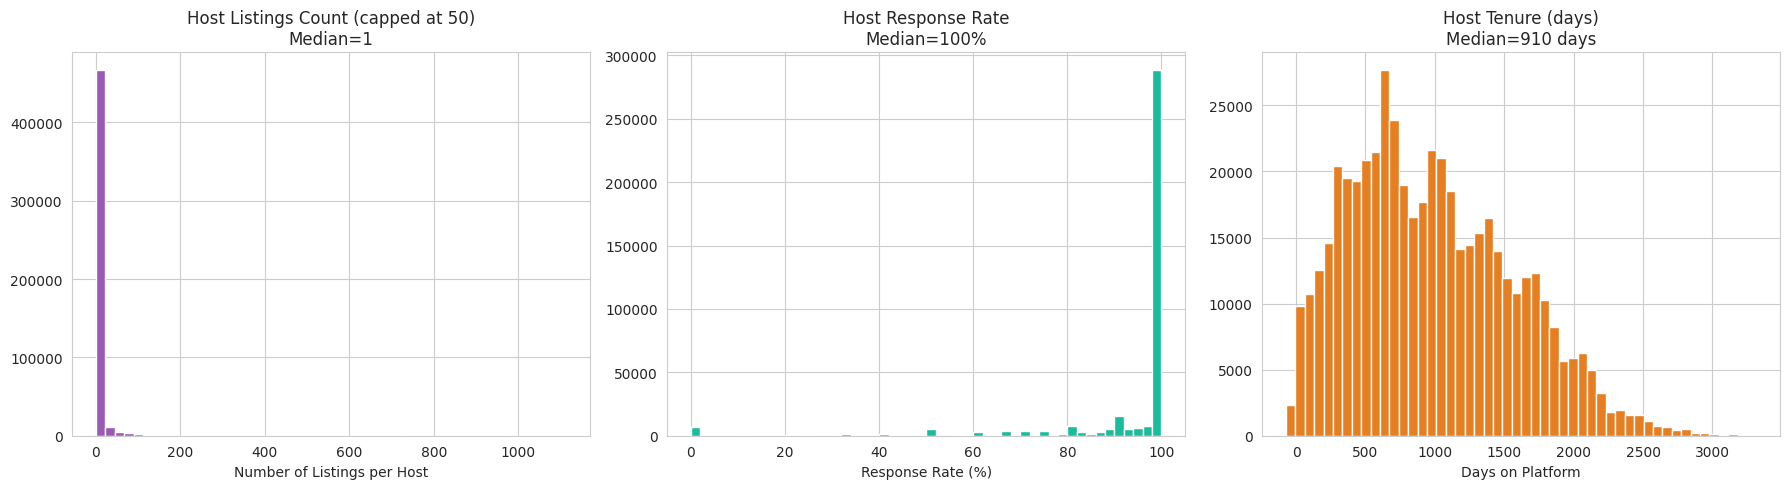

Hosts with multiple listings: 203,676 (41.2%)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

host_lc = pd.to_numeric(df["Host Listings Count"], errors="coerce")

axes[0].hist(host_lc.dropna(), bins=50, color="#9b59b6", edgecolor="white")
axes[0].set_title(f"Host Listings Count (capped at 50)\nMedian={host_lc.median():.0f}")
axes[0].set_xlabel("Number of Listings per Host")

df["Host Response Rate"] = (
    df["Host Response Rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df["Host Response Rate"] = pd.to_numeric(df["Host Response Rate"], errors="coerce")
resp = df["Host Response Rate"].dropna()

axes[1].hist(resp, bins=50, color="#1abc9c", edgecolor="white")
axes[1].set_title(f"Host Response Rate\nMedian={resp.median():.0f}%")
axes[1].set_xlabel("Response Rate (%)")

host_since = pd.to_datetime(df["Host Since"], errors="coerce")
ref = pd.Timestamp("2017-04-02")

tenure = (ref - host_since).dt.days.dropna()

axes[2].hist(tenure, bins=50, color="#e67e22", edgecolor="white")
axes[2].set_title(f"Host Tenure (days)\nMedian={tenure.median():.0f} days")
axes[2].set_xlabel("Days on Platform")

plt.tight_layout()
plt.show()

multi = (pd.to_numeric(df["Host Listings Count"], errors="coerce") > 1).sum()

print(f"Hosts with multiple listings: {multi:,} ({multi/len(df)*100:.1f}%)")

## 12. Top Markets & Cities by Listing Count

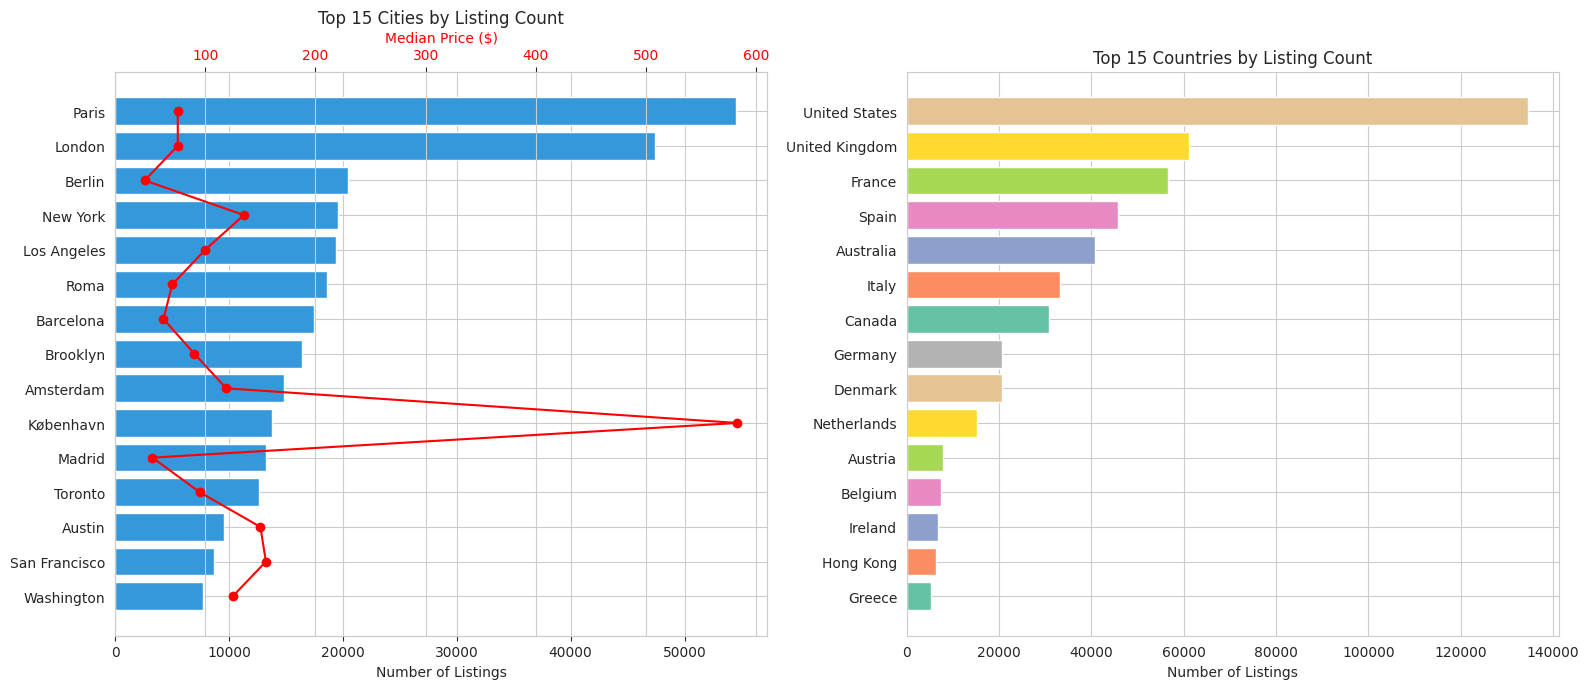

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 cities
city_counts = df["City"].value_counts().head(15)
city_median_price = df.groupby("City")["Price"].median().loc[city_counts.index]

ax1 = axes[0]
bars = ax1.barh(city_counts.index[::-1], city_counts.values[::-1], color="#3498db")
ax1.set_title("Top 15 Cities by Listing Count")
ax1.set_xlabel("Number of Listings")

ax1_twin = ax1.twiny()
ax1_twin.plot(
    city_median_price.values[::-1], city_counts.index[::-1], "ro-", markersize=6
)
ax1_twin.set_xlabel("Median Price ($)", color="red")
ax1_twin.tick_params(axis="x", labelcolor="red")

# Top 15 countries
country_counts = df["Country"].value_counts().head(15)
axes[1].barh(
    country_counts.index[::-1],
    country_counts.values[::-1],
    color=sns.color_palette("Set2", 15),
)
axes[1].set_title("Top 15 Countries by Listing Count")
axes[1].set_xlabel("Number of Listings")

plt.tight_layout()
plt.show()

## 13. Outlier Detection
Boxplots revealing extreme values that need capping during preprocessing.

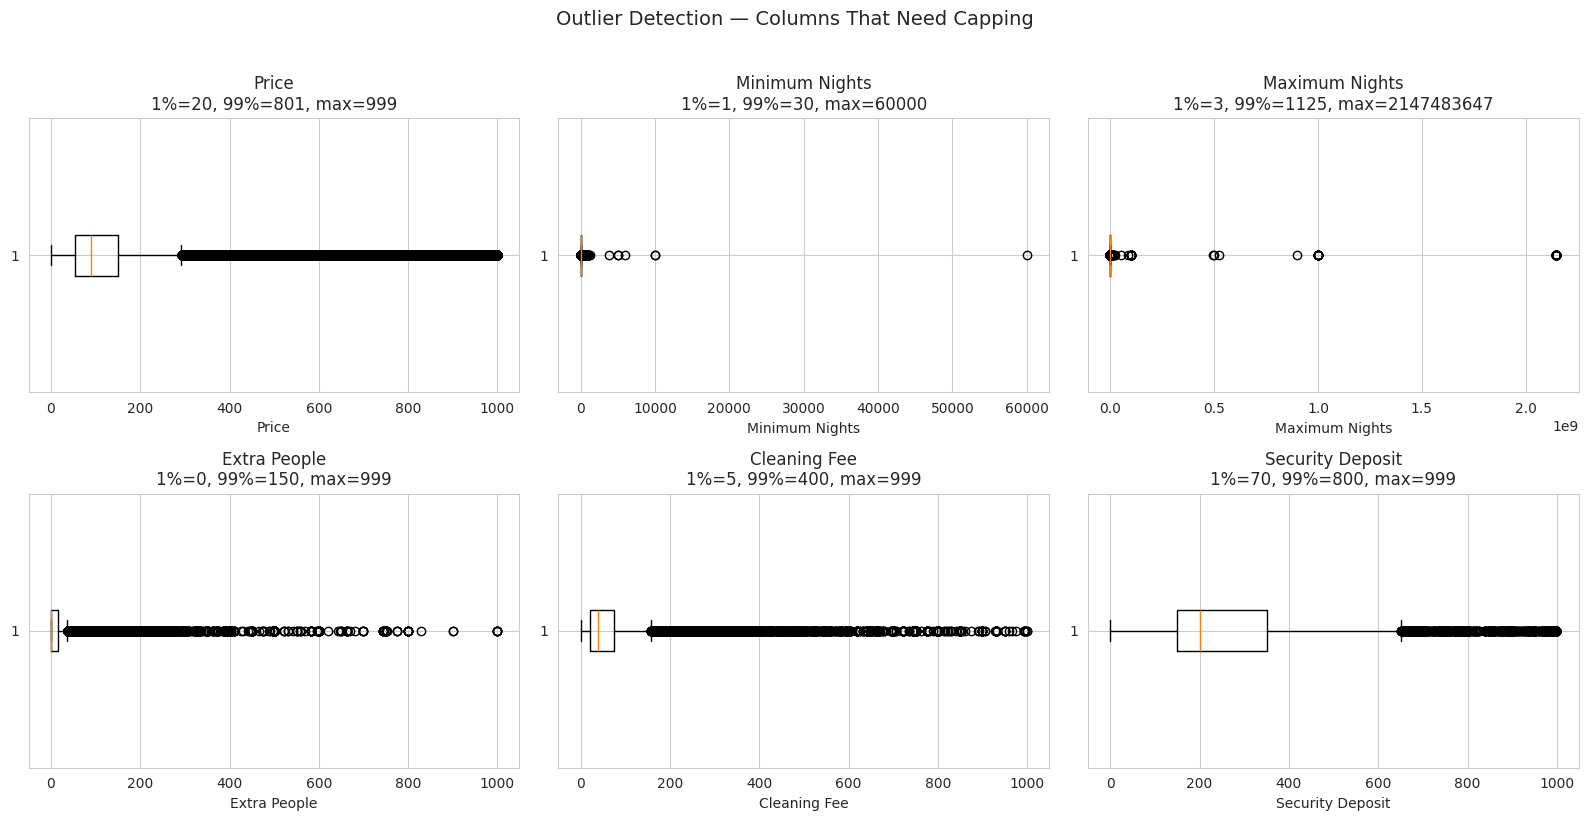

In [15]:
outlier_cols = [
    "Price",
    "Minimum Nights",
    "Maximum Nights",
    "Extra People",
    "Cleaning Fee",
    "Security Deposit",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    df[col] = pd.to_numeric(df[col], errors="coerce")  # ensure numeric

    data = df[col].dropna()

    axes[i].boxplot(data, vert=False)

    q01 = data.quantile(0.01)
    q99 = data.quantile(0.99)

    axes[i].set_title(f"{col}\n1%={q01:.0f}, 99%={q99:.0f}, max={data.max():.0f}")
    axes[i].set_xlabel(col)

plt.suptitle("Outlier Detection — Columns That Need Capping", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. EDA Summary & Preprocessing Justification

**Key Findings:**

1. **Missing values:** `Square Feet` (97.5%), `License` (97%), `Has Availability` (98%), `Host Acceptance Rate` (91.5%), `Neighbourhood Group Cleansed` (79%) are too sparse → **drop them**.

2. **Price distribution** is heavily right-skewed with extreme outliers (max in the tens of thousands). Most listings are under $300/night. → **Cap at 1st–99th percentile**.

3. **Room Type** strongly influences price: Entire home/apt >> Private room >> Shared room.

4. **Amenities** are stored as comma-separated strings. Top amenities (Wifi, Kitchen, Heating) appear in the vast majority of listings. → **Parse into count + top-20 one-hot flags**.

5. **Host Verifications** and **Features** are also comma-separated strings that need parsing into structured features.

6. **Date columns** (`Host Since`, `First Review`, `Last Review`) should be converted to days-since for numerical analysis.

7. **Minimum/Maximum Nights** have extreme outliers (some listings set 999+ nights). → **Cap outliers**.

8. **Experiences Offered** is 99.35% "none" → near-zero variance → **drop**.

9. **URL, free-text, scrape metadata, and PII columns** carry no analytical signal → **drop 34 columns total**.

10. **Categorical columns** like `Property Type`, `Room Type`, `City`, `Country` need encoding for modeling.

These findings directly drove the decisions in `preprocessing.py`.